<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/04_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import numpy as np
from scipy.sparse import load_npz

uploaded = files.upload()  # Upload X_train.npz, X_test.npz, y_train.npy, y_test.npy

X_train = load_npz('X_train.npz')
X_test = load_npz('X_test.npz')
y_train = np.load('y_train.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Saving X_test.npz to X_test.npz
Saving X_train.npz to X_train.npz
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy
Data loaded successfully!
X_train shape: (4135, 5000)
X_test shape: (1034, 5000)


In [2]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = lr_model.predict(X_test)

print("=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, pos_label='spam'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Logistic Regression Results ===
Accuracy:  0.9536
Precision: 0.9770
Recall:    0.6489
F1 Score:  0.7798

Classification Report:
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       903
        spam       0.98      0.65      0.78       131

    accuracy                           0.95      1034
   macro avg       0.96      0.82      0.88      1034
weighted avg       0.95      0.95      0.95      1034



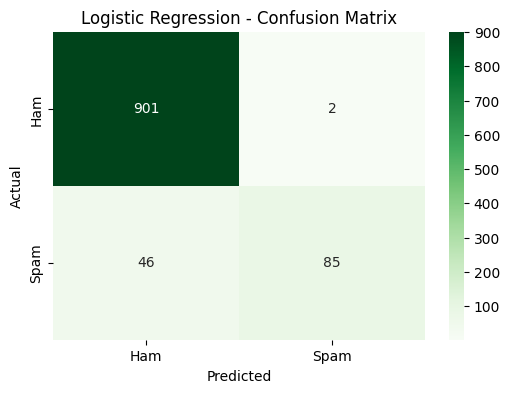

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('lr_confusion_matrix.png')
plt.show()

In [5]:
import json

lr_results = {
    'model': 'Logistic Regression',
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, pos_label='spam'),
    'recall': recall_score(y_test, y_pred, pos_label='spam'),
    'f1': f1_score(y_test, y_pred, pos_label='spam')
}

with open('lr_results.json', 'w') as f:
    json.dump(lr_results, f)

print("Results saved!")
print(lr_results)

Results saved!
{'model': 'Logistic Regression', 'accuracy': 0.9535783365570599, 'precision': 0.9770114942528736, 'recall': 0.648854961832061, 'f1': 0.7798165137614679}
